<a href="https://colab.research.google.com/github/suakhongduong123/du_doan_khi_nao_khach_hang_tro_lai_mua_hang/blob/main/src/Customer_return.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
import warnings

warnings.filterwarnings('ignore')

warnings.filterwarnings('ignore')

# Cấu hình hiển thị biểu đồ
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})
sns.set_style('whitegrid')
sns.set_palette('husl')

In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = '/content/drive/MyDrive/customer_data/'
# Tải 7 files
try:
    customers = pd.read_csv(os.path.join(DATA_PATH, 'customers.csv'))
    transactions = pd.read_csv(os.path.join(DATA_PATH, 'transactions.csv'))
    transaction_items = pd.read_csv(os.path.join(DATA_PATH, 'transaction_items.csv'))
    products = pd.read_csv(os.path.join(DATA_PATH, 'products.csv'))
    support = pd.read_csv(os.path.join(DATA_PATH, 'customer_support.csv'))
    marketing = pd.read_csv(os.path.join(DATA_PATH, 'marketing_touchpoints.csv'))
    stores = pd.read_csv(os.path.join(DATA_PATH, 'stores.csv'))

    print("Đã tải thành công 7 file dữ liệu.")
except FileNotFoundError as e:
    print(f"Lỗi: {e}. Vui lòng kiểm tra lại cấu trúc thư mục.")

Mounted at /content/drive
Đã tải thành công 7 file dữ liệu.


#kiểm tra chất lượng data
tạo bảng để Kiểm tra số dòng, cột, số lượng duplicates, tỉ lệ missing value, key colum của các file dữ liệu

In [ ]:
datasets = {
    'customers.csv': (customers, 'customer_id'),
    'transactions.csv': (transactions, 'transaction_id'),
    'transaction_items.csv': (transaction_items, 'transaction_id + product_id'),
    'products.csv': (products, 'product_id'),
    'customer_support.csv': (support, 'ticket_id'),
    'marketing_touchpoints.csv': (marketing, 'campaign_id + customer_id'),
    'stores.csv': (stores, 'store_id')
}

summary_data = []
for name, (df, keys) in datasets.items():
    missing_pct = df.isnull().mean().mean() * 100 # Tỷ lệ thiếu trung bình
    dups = df.duplicated().sum()
    summary_data.append({
        'Tập tin': name,
        'Số dòng': len(df),
        'Số cột': len(df.columns),
        'Thiếu trung bình (%)': f"{missing_pct:.2f}%",
        'Trùng lặp': dups,
        'Khóa chính': keys
    })

summary_df = pd.DataFrame(summary_data)
display(summary_df.style.set_properties(**{'text-align': 'left'}).set_table_styles
 ([{'selector': 'th', 'props': [('text-align', 'left')]}]))

,Tập tin,Số dòng,Số cột,Thiếu trung bình (%),Trùng lặp,Khóa chính
0,customers.csv,800,6,3.73%,0,customer_id
1,transactions.csv,3500,6,1.69%,0,transaction_id
2,transaction_items.csv,7740,4,2.52%,0,transaction_id + product_id
3,products.csv,150,6,1.00%,0,product_id
4,customer_support.csv,700,7,5.57%,0,ticket_id
5,marketing_touchpoints.csv,1800,8,2.70%,0,campaign_id + customer_id
6,stores.csv,25,5,0.00%,0,store_id


# thống kê chi tiết


In [ ]:
# Hàm hỗ trợ để hiển thị describe() + info() một cách gọn gàng
def display_dataset_info(df, name):
    display(Markdown(f"###  Thống kê của: `{name}`"))

    # Các giá trị bị thiếu
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if not missing.empty:
        display(Markdown("**Các cột có giá trị thiếu (Mức độ thiếu Values):**"))
        display(pd.DataFrame({'Số lượng thiếu': missing, '% Mức độ thiếu': (missing/len(df)*100).round(2)}))
    else:
        display(Markdown("**Không có giá trị thiếu trong tập dữ liệu này.**"))

    display(Markdown("**Thống kê mô tả (Numeric):**"))
    display(df.describe().round(2))

    display(Markdown("**Thống kê mô tả (Categorical):**"))
    cats = df.select_dtypes(include=['object']).columns
    if len(cats) > 0:
        display(df[cats].describe())

# Hiển thị toàn bộ 7 bảng
datasets_to_display = [
    (customers, 'customers.csv'),
    (transactions, 'transactions.csv'),
    (transaction_items, 'transaction_items.csv'),
    (products, 'products.csv'),
    (stores, 'stores.csv'),
    (support, 'customer_support.csv'),
    (marketing, 'marketing_campaigns.csv')
]

for df_obj, name in datasets_to_display:
    display_dataset_info(df_obj, name)

###  Thống kê của: `customers.csv`

**Không có giá trị thiếu trong tập dữ liệu này.**

**Thống kê mô tả (Numeric):**

,birth_year,registration_date
count,800.00,800
mean,1985.20,2024-06-22 10:22:48.000000256
min,1940.00,2023-06-01 00:00:00
25%,1976.00,2023-12-10 00:00:00
50%,1986.00,2024-06-25 12:00:00
75%,1995.00,2024-12-29 00:00:00
max,2006.00,2025-06-30 00:00:00
std,12.42,NaN


**Thống kê mô tả (Categorical):**

...

,Số lượng thiếu,% Mức độ thiếu
channel,101,5.61


**Thống kê mô tả (Numeric):**

,sent_date,is_opened,is_clicked,offer_value
count,1800,1800.00,1800.00,1800.00
mean,2025-05-17 02:41:36,0.37,0.09,16044.58
min,2023-06-14 00:00:00,0.00,0.00,0.00
25%,2024-12-29 18:00:00,0.00,0.00,0.00
50%,2025-06-29 00:00:00,0.00,0.00,10000.00
75%,2025-11-14 00:00:00,1.00,0.00,20000.00
max,2026-03-25 00:00:00,1.00,1.00,500000.00
std,NaN,0.48,0.29,30116.31


**Thống kê mô tả (Categorical):**

,campaign_id,customer_id,channel,campaign_type
count,1800,1800,1699,1800
unique,50,711,6,8
top,MKT002,C00618,Zalo OA,Holiday
freq,36,8,303,253


In [ ]:
# Kiểm chứng độ nhiễu Format của cột Boolean trong Marketing Campaigns
print("Các giá trị Unique của 'is_opened':")
print(marketing['is_opened'].unique())
print("\nCác giá trị Unique của 'is_clicked':")
print(marketing['is_clicked'].unique())

Các giá trị Unique của 'is_opened':
['0' '1' nan 'TRUE' '2' 'Yes' '-1']

Các giá trị Unique của 'is_clicked':
['0' '1' 'Yes' nan '2' 'TRUE' '-1']


#phân tích trực quan từng file dữ
## tập tin 1: customer

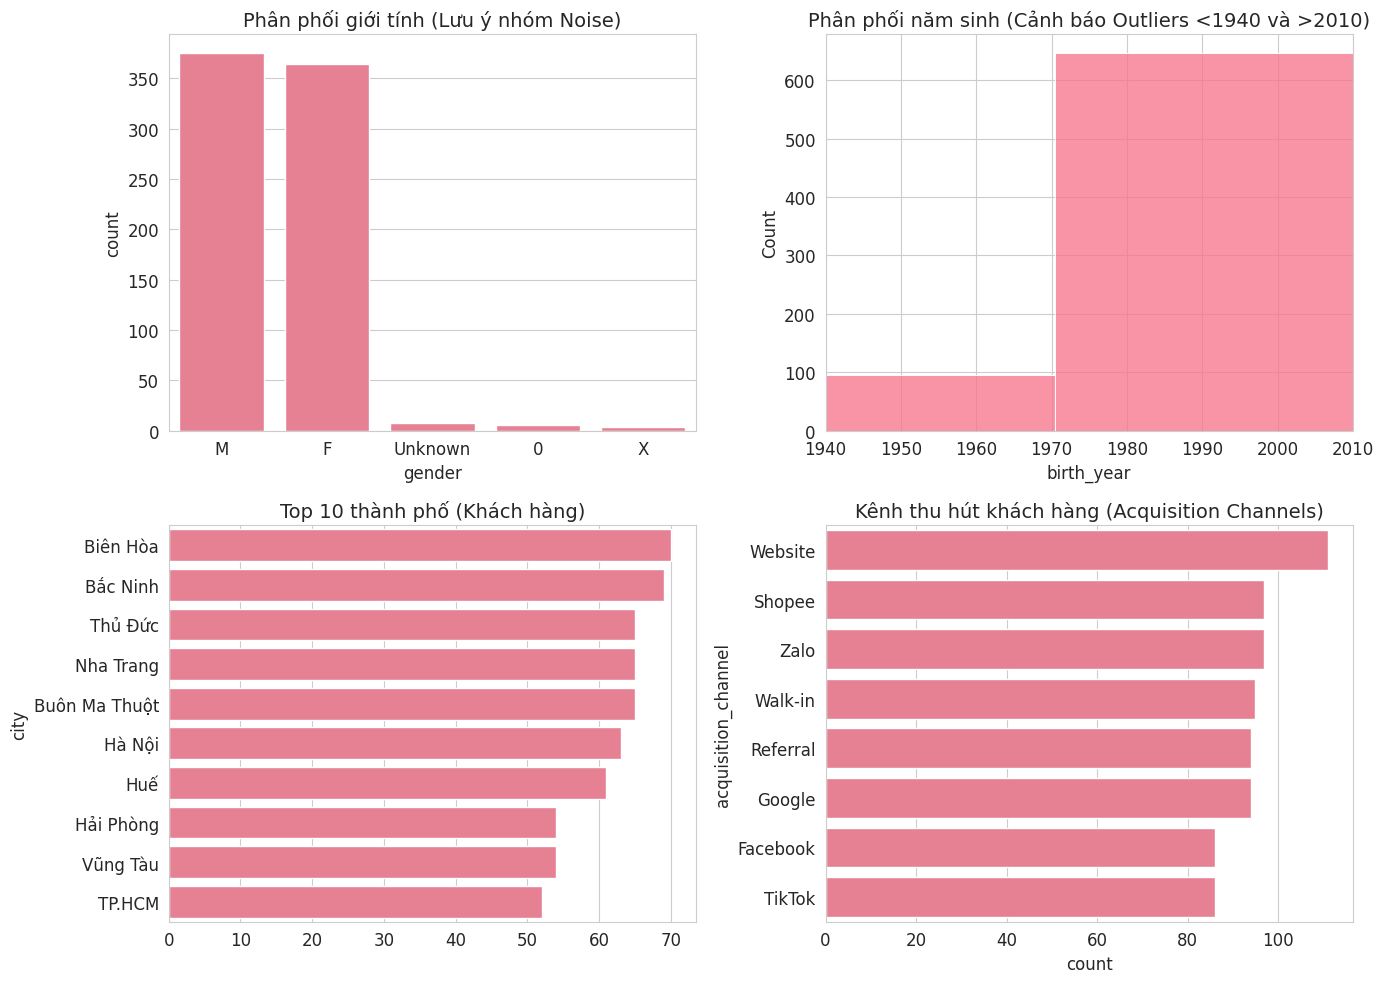

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# [Ax1] Gender distribution
sns.countplot(data=customers, x='gender', ax=axes[0,0], order=customers['gender'].value_counts().index)
axes[0,0].set_title('Phân phối giới tính (Lưu ý nhóm Noise)')

# [Ax2] Birth year distribution (Zoom into realistic typical range + show outliers contextually if possible)
sns.histplot(data=customers, x='birth_year', bins=50, ax=axes[0,1])
axes[0,1].set_title('Phân phối năm sinh (Cảnh báo Outliers <1940 và >2010)')
# Limit x-axis to make it readable, but note outliers exist
axes[0,1].set_xlim(1940, 2010)

# [Ax3] Top 10 Cities
top_cities = customers['city'].value_counts().head(10)
sns.barplot(y=top_cities.index, x=top_cities.values, ax=axes[1,0], orient='h')
axes[1,0].set_title('Top 10 thành phố (Khách hàng)')

# [Ax4] Acquisition Channel
sns.countplot(data=customers, y='acquisition_channel', ax=axes[1,1], order=customers['acquisition_channel'].value_counts().index)
axes[1,1].set_title('Kênh thu hút khách hàng (Acquisition Channels)')

plt.tight_layout()
plt.show()

#tập tin 2: transactions

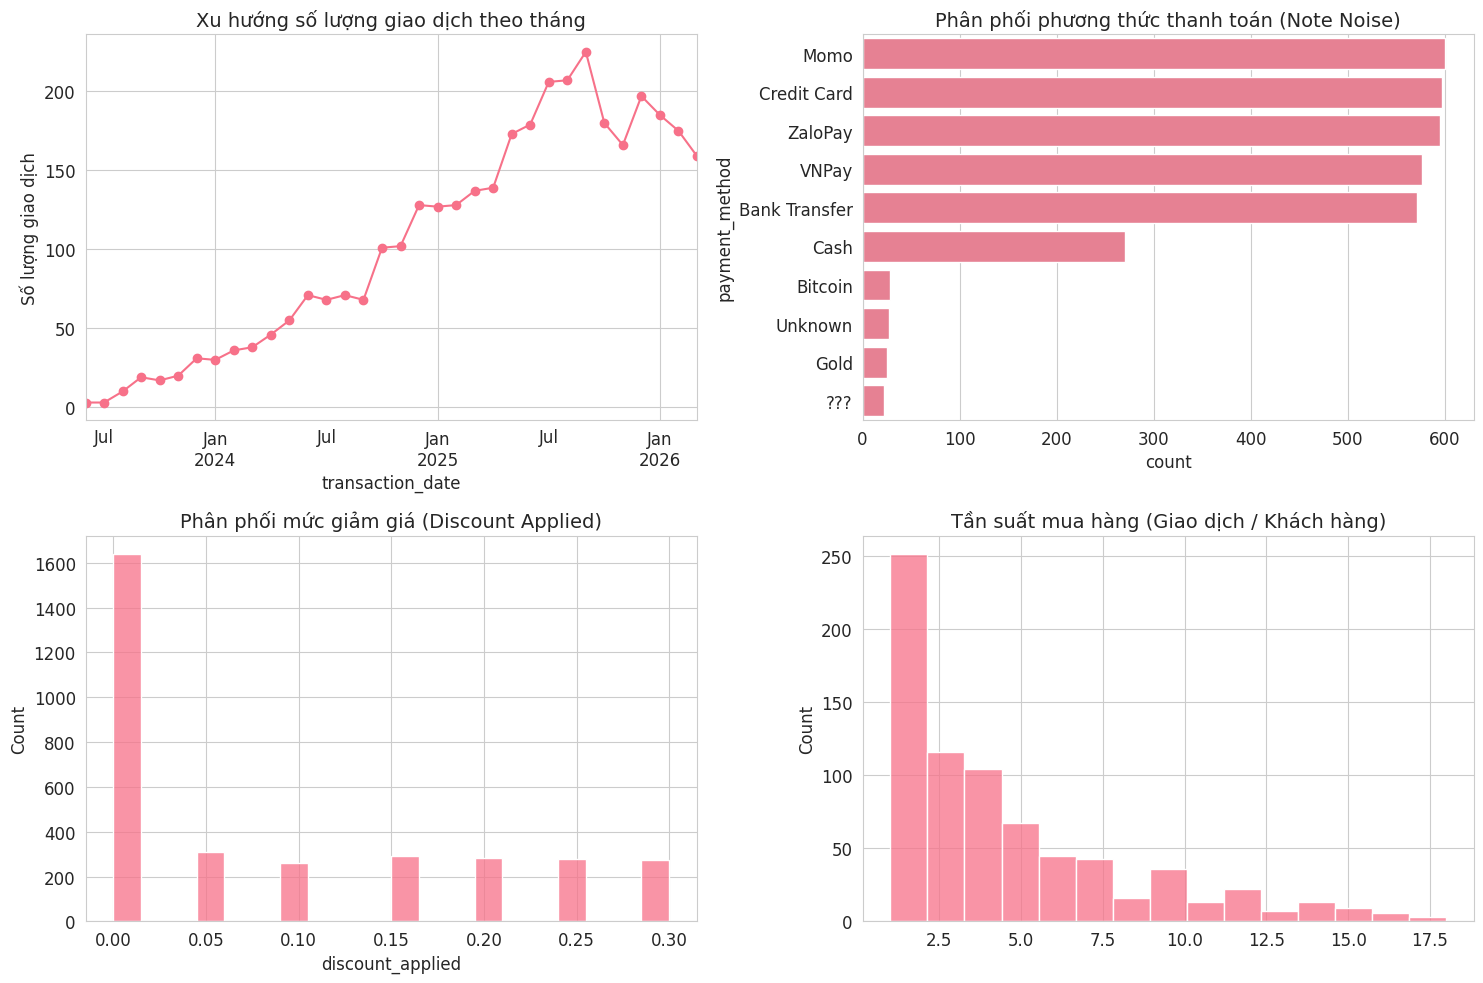

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Đảm bảo transaction_date là kiểu datetime
transactions['transaction_date'] = pd.to_datetime(transactions['transaction_date'], errors='coerce')
tx_monthly = transactions.set_index('transaction_date').resample('ME').size()

# [Ax1] Giao dịch theo thời gian
tx_monthly.plot(ax=axes[0,0], marker='o')
axes[0,0].set_title('Xu hướng số lượng giao dịch theo tháng')
axes[0,0].set_ylabel('Số lượng giao dịch')

# [Ax2] Phương thức thanh toán
sns.countplot(data=transactions, y='payment_method', ax=axes[0,1], order=transactions['payment_method'].value_counts().index)
axes[0,1].set_title('Phân phối phương thức thanh toán (Note Noise)')

# [Ax3] Giảm giá
sns.histplot(data=transactions, x='discount_applied', bins=20, ax=axes[1,0])
axes[1,0].set_title('Phân phối mức giảm giá (Discount Applied)')

# [Ax4] Giao dịch mỗi khách hàng
tx_per_cust = transactions.groupby('customer_id').size()
sns.histplot(tx_per_cust, bins=15, ax=axes[1,1])
axes[1,1].set_title('Tần suất mua hàng (Giao dịch / Khách hàng)')

plt.tight_layout()
plt.show()

In [ ]:
# Thống kê Cross-check độ phủ khách hàng (Orphans)
total_customers = len(customers)
customers_with_tx = transactions['customer_id'].nunique()
orphan_customers = total_customers - customers_with_tx
orphan_percentage = (orphan_customers / total_customers) * 100

print(f"Tổng số khách hàng đăng ký (customers.csv): {total_customers}")
print(f"Số khách hàng đã phát sinh giao dịch: {customers_with_tx} ({customers_with_tx/total_customers*100:.1f}%)")
print(f"Cảnh báo: Có {orphan_customers} khách hàng ({orphan_percentage:.1f}%) rơi vào trạng thái Câm/Orphan (Chưa từng giao dịch).")

Tổng số khách hàng đăng ký (customers.csv): 800
Số khách hàng đã phát sinh giao dịch: 751 (93.9%)
Cảnh báo: Có 49 khách hàng (6.1%) rơi vào trạng thái Câm/Orphan (Chưa từng giao dịch).


##Tập tin 3: transaction_items.csv

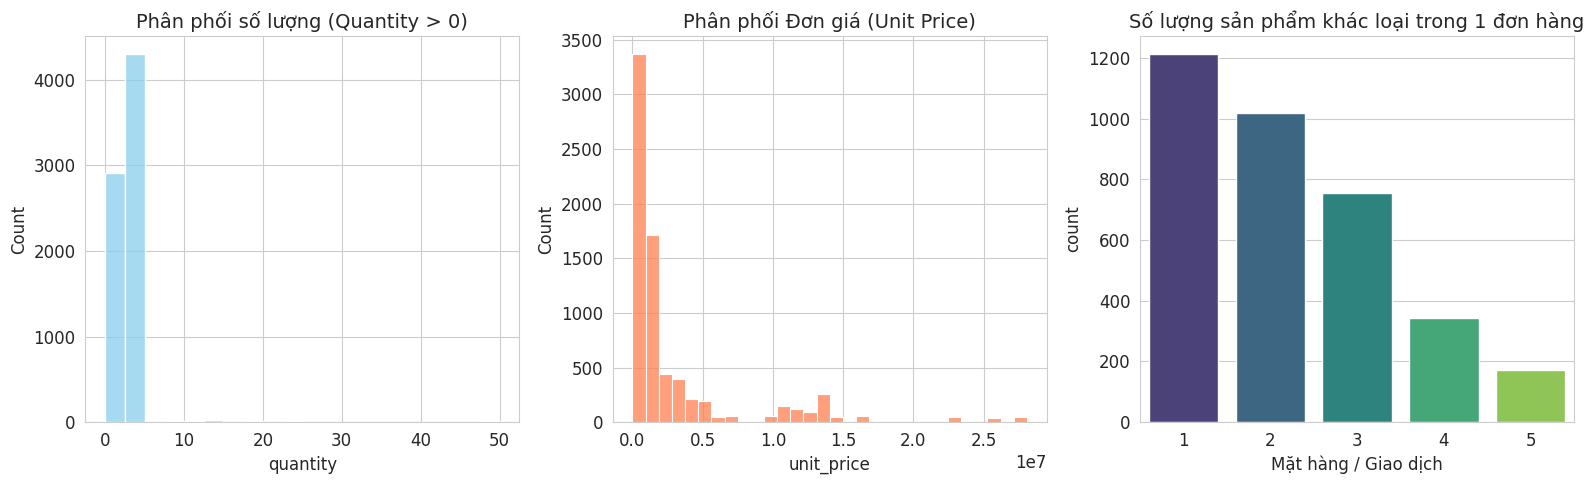

**Cảnh báo nghiêm trọng:** Có `41` dòng giá trị quantity bị Nhỏ Hơn 0 (âm). Sự tồn tại này củng cố thuật toán giữ nguyên để dò tìm Return/Refund.

**Kiểm chứng Đơn giá (Unit Price):** Max = `28,089,000 VNĐ`, trong khi Median chỉ là `1,134,000 VNĐ`. Độ lệch (Skewness) = `2.70` (Rất cao). Dữ liệu lệch phải cực đoan (Right-skewed).

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# [Ax1] Quantity distribution
sns.histplot(transaction_items[transaction_items['quantity'] > 0]['quantity'], bins=20, ax=axes[0], color='skyblue', label='> 0')
axes[0].set_title('Phân phối số lượng (Quantity > 0)')

# [Ax2] Unit price distribution
sns.histplot(transaction_items['unit_price'], bins=30, ax=axes[1], color='coral')
axes[1].set_title('Phân phối Đơn giá (Unit Price)')

# [Ax3] Items per transaction
items_per_tx = transaction_items.groupby('transaction_id').size()
sns.countplot(x=items_per_tx, ax=axes[2], palette='viridis')
axes[2].set_title('Số lượng sản phẩm khác loại trong 1 đơn hàng')
axes[2].set_xlabel('Mặt hàng / Giao dịch')

plt.tight_layout()
plt.show()

# Đánh dấu rủi ro và Kiểm chứng độ lệch Unit Price
negative_qty = (transaction_items['quantity'] < 0).sum()
display(Markdown(f"**Cảnh báo nghiêm trọng:** Có `{negative_qty}` dòng giá trị quantity bị Nhỏ Hơn 0 (âm). Sự tồn tại này củng cố thuật toán giữ nguyên để dò tìm Return/Refund."))

max_price = transaction_items['unit_price'].max()
median_price = transaction_items['unit_price'].median()
skewness = transaction_items['unit_price'].skew()

display(Markdown(f"**Kiểm chứng Đơn giá (Unit Price):** Max = `{max_price:,.0f} VNĐ`, trong khi Median chỉ là `{median_price:,.0f} VNĐ`. Độ lệch (Skewness) = `{skewness:.2f}` (Rất cao). Dữ liệu lệch phải cực đoan (Right-skewed)."))

##Tập tin 4 & 5: products.csv và stores.csv

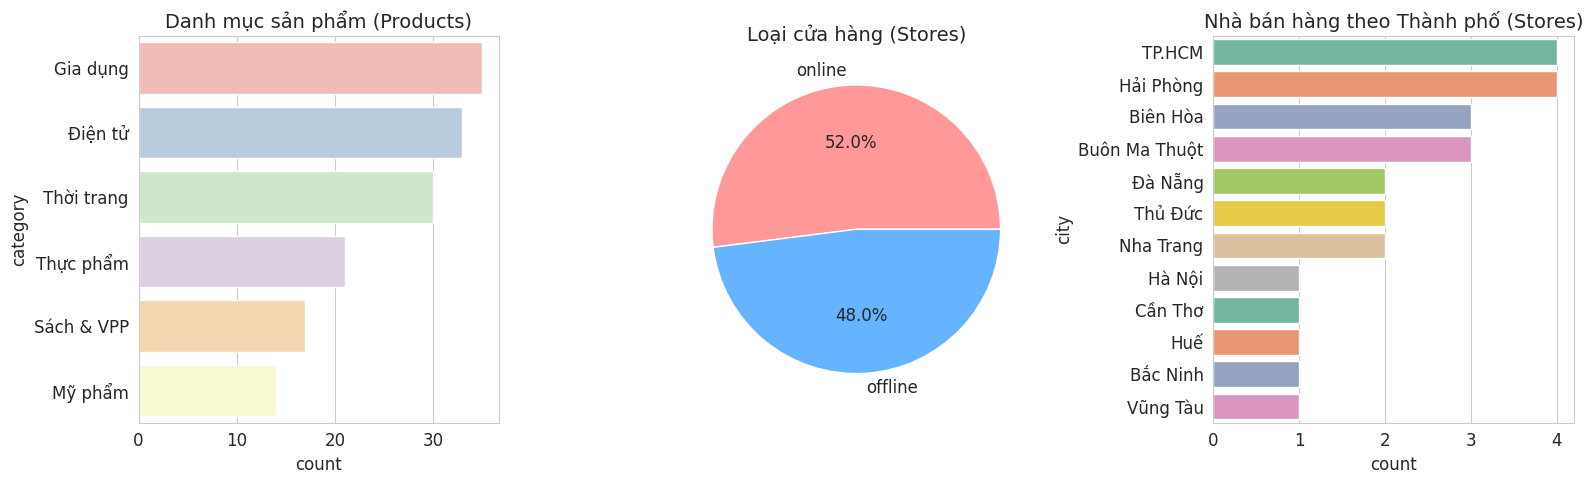

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Products
sns.countplot(data=products, y='category', ax=axes[0], order=products['category'].value_counts().index, palette='Pastel1')
axes[0].set_title('Danh mục sản phẩm (Products)')

# Store Type
stores['store_type'].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[1], colors=['#ff9999','#66b3ff'])
axes[1].set_title('Loại cửa hàng (Stores)')
axes[1].set_ylabel('')

# Store by City
sns.countplot(data=stores, y='city', ax=axes[2], order=stores['city'].value_counts().index, palette='Set2')
axes[2].set_title('Nhà bán hàng theo Thành phố (Stores)')

plt.tight_layout()
plt.show()

##Tập tin 6: customer_support.csv

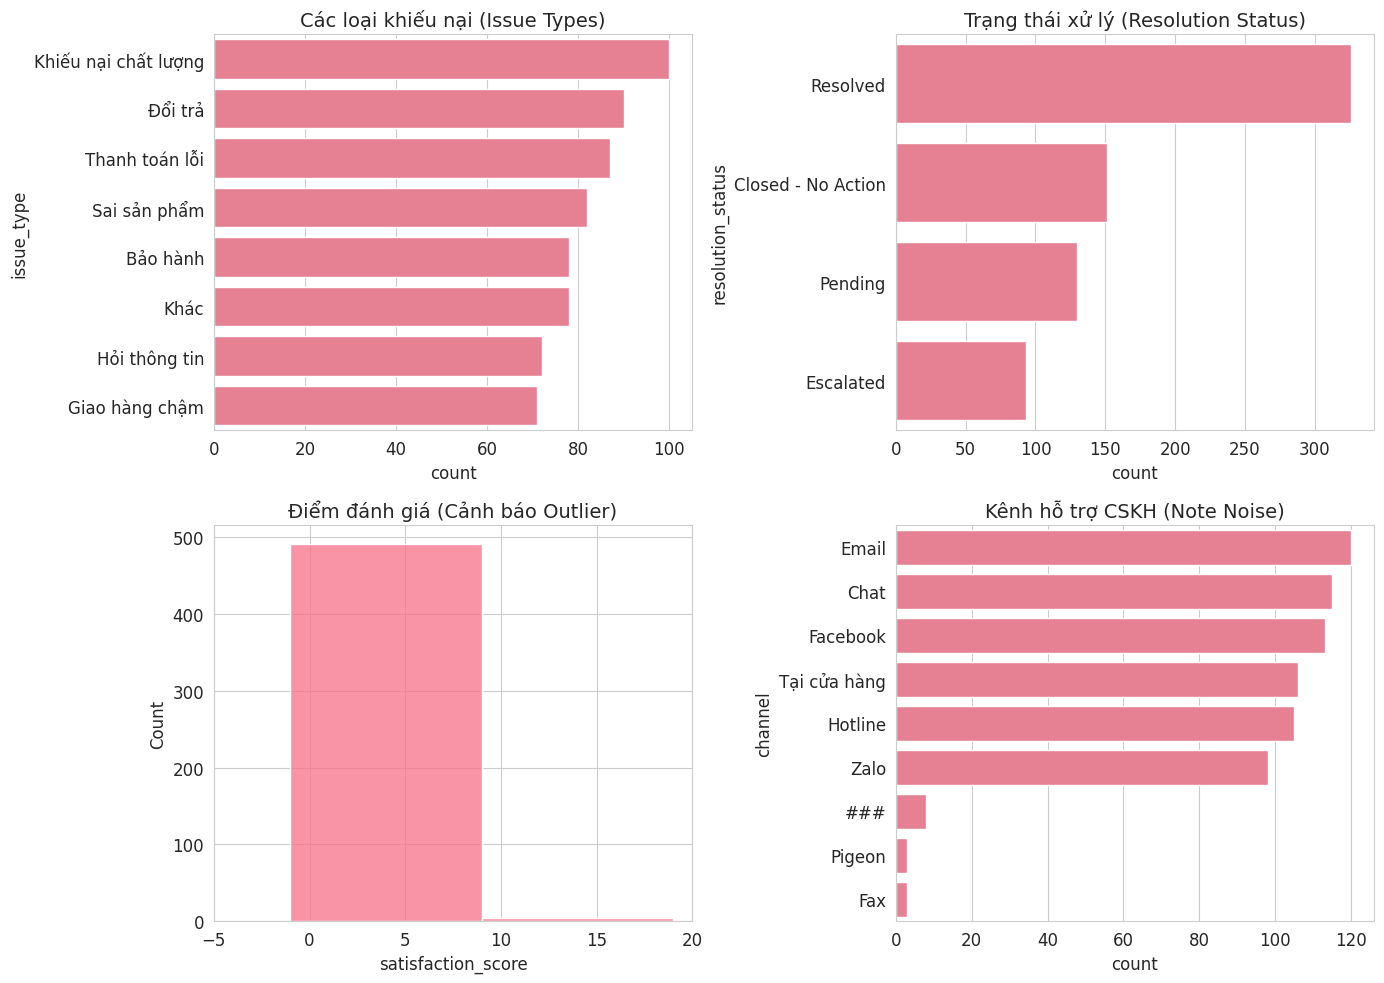

Thống kê tương tác CSKH:
- Số khách hàng có liên hệ CSKH: 448/800 (56.0%)
- Cảnh báo Data: Giá trị Satisfaction Score định mức (1-5), nhưng ghi nhận Max = 99.0


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# [Ax1] Issue type
sns.countplot(data=support, y='issue_type', ax=axes[0,0], order=support['issue_type'].value_counts().index)
axes[0,0].set_title('Các loại khiếu nại (Issue Types)')

# [Ax2] Resolution status
sns.countplot(data=support, y='resolution_status', ax=axes[0,1], order=support['resolution_status'].value_counts().index)
axes[0,1].set_title('Trạng thái xử lý (Resolution Status)')

# [Ax3] Satisfaction score
sns.histplot(data=support, x='satisfaction_score', bins=10, ax=axes[1,0])
axes[1,0].set_title('Điểm đánh giá (Cảnh báo Outlier)')
axes[1,0].set_xlim(-5, 20) # restrict view to show anomalies early

# [Ax4] Support channel
sns.countplot(data=support, y='channel', ax=axes[1,1], order=support['channel'].value_counts().index)
axes[1,1].set_title('Kênh hỗ trợ CSKH (Note Noise)')

plt.tight_layout()
plt.show()

# Tính toán độ phủ và Noise
total_customers = len(customers)
cs_customers = support['customer_id'].nunique()
cs_coverage = (cs_customers / total_customers) * 100

print(f"Thống kê tương tác CSKH:")
print(f"- Số khách hàng có liên hệ CSKH: {cs_customers}/{total_customers} ({cs_coverage:.1f}%)")
print(f"- Cảnh báo Data: Giá trị Satisfaction Score định mức (1-5), nhưng ghi nhận Max = {support['satisfaction_score'].max()}")

##Tập tin 7: marketing_touchpoints.csv

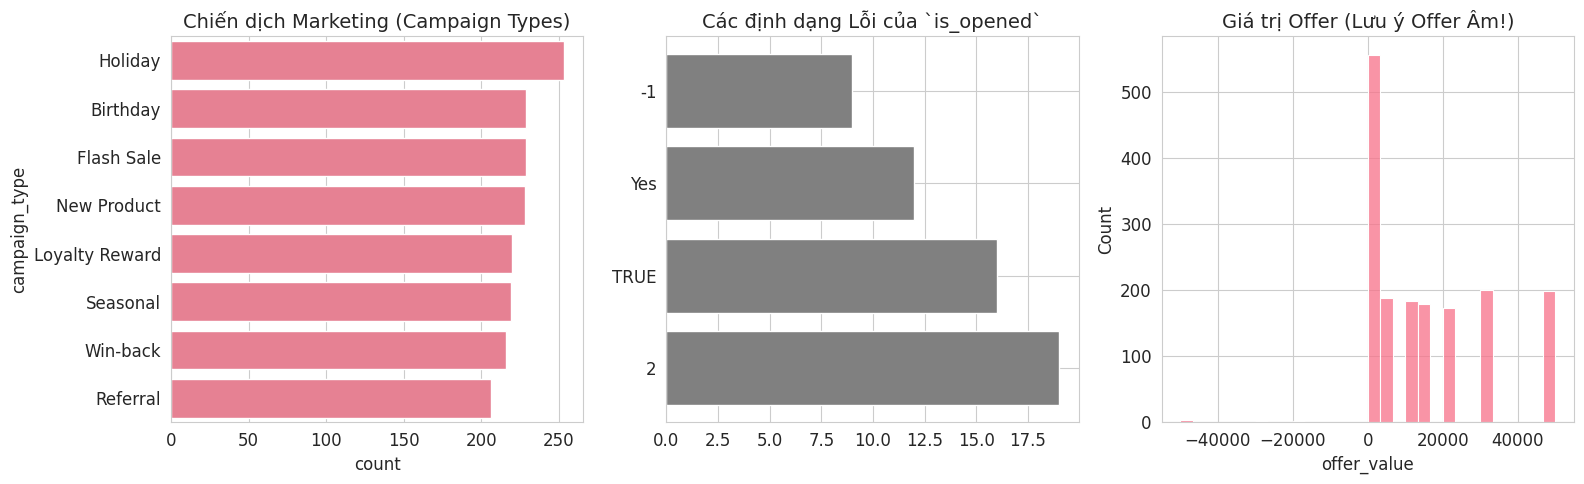

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# [Ax1] Campaign type
sns.countplot(data=marketing, y='campaign_type', ax=axes[0], order=marketing['campaign_type'].value_counts().index)
axes[0].set_title('Chiến dịch Marketing (Campaign Types)')

# [Ax2] is_opened and is_clicked Noise
invalid_opened = marketing[~marketing['is_opened'].isin([0, 1, '0', '1', 0.0, 1.0])]['is_opened'].value_counts()
invalid_clicked = marketing[~marketing['is_clicked'].isin([0, 1, '0', '1', 0.0, 1.0])]['is_clicked'].value_counts()

axes[1].barh(range(len(invalid_opened)), invalid_opened.values, align='center', color='gray')
axes[1].set_yticks(range(len(invalid_opened)), [str(x)[:10] for x in invalid_opened.index])
axes[1].set_title('Các định dạng Lỗi của `is_opened`')

# [Ax3] offer_value distribution (filtered extreme extremes for plotting)
sns.histplot(marketing[(marketing['offer_value'] > -100000) & (marketing['offer_value'] < 100000)]['offer_value'], bins=30, ax=axes[2])
axes[2].set_title('Giá trị Offer (Lưu ý Offer Âm!)')

plt.tight_layout()
plt.show()

#Mối quan hệ giữa các bảng (ERD)


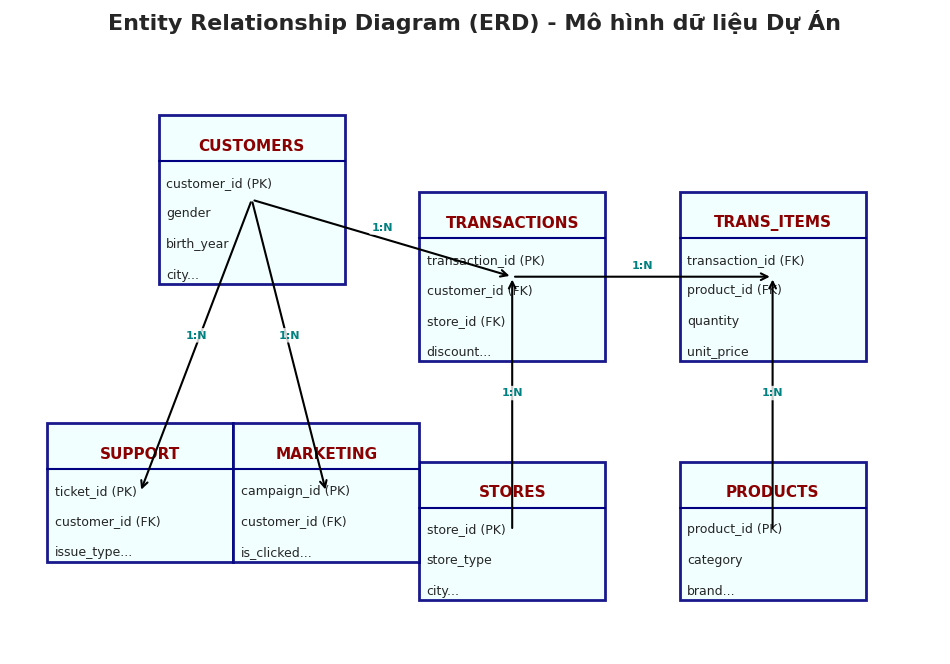

In [ ]:
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(12, 8))

def draw_table(ax, x, y, title, columns, width=2.5, height_per_row=0.4):
    height = height_per_row * (len(columns) + 1.5)
    rect = patches.Rectangle((x, y-height), width, height, linewidth=2, edgecolor='navy', facecolor='azure', alpha=0.9)
    ax.add_patch(rect)
    ax.text(x + width/2, y - height_per_row, title, ha='center', va='center', fontweight='bold', fontsize=11, color='darkred')
    ax.plot([x, x+width], [y - 1.5*height_per_row, y - 1.5*height_per_row], color='navy')

    for i, col in enumerate(columns):
        ax.text(x + 0.1, y - (i+2.2)*height_per_row, col, ha='left', va='center', fontsize=9)
    return (x + width/2, y - height/2)

# Definitions
tables = {
    'CUSTOMERS': (1.5, 7, ['customer_id (PK)', 'gender', 'birth_year', 'city...']),
    'TRANSACTIONS': (5, 6, ['transaction_id (PK)', 'customer_id (FK)', 'store_id (FK)', 'discount...']),
    'TRANS_ITEMS': (8.5, 6, ['transaction_id (FK)', 'product_id (FK)', 'quantity', 'unit_price']),
    'PRODUCTS': (8.5, 2.5, ['product_id (PK)', 'category', 'brand...']),
    'STORES': (5, 2.5, ['store_id (PK)', 'store_type', 'city...']),
    'SUPPORT': (0, 3, ['ticket_id (PK)', 'customer_id (FK)', 'issue_type...']),
    'MARKETING': (2.5, 3, ['campaign_id (PK)', 'customer_id (FK)', 'is_clicked...'])
}

centers = {}
for name, (x, y, cols) in tables.items():
    centers[name] = draw_table(ax, x, y, name, cols)

# Draw relations
def connect(name1, name2, ax, text):
    x1, y1 = centers[name1]
    x2, y2 = centers[name2]
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1), arrowprops=dict(arrowstyle="->", color="black", lw=1.5))
    ax.text((x1+x2)/2, (y1+y2)/2 + 0.1, text, color='teal', fontsize=8, fontweight='bold', ha='center',
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.8))

connect('CUSTOMERS', 'TRANSACTIONS', ax, "1:N")
connect('CUSTOMERS', 'SUPPORT', ax, "1:N")
connect('CUSTOMERS', 'MARKETING', ax, "1:N")
connect('TRANSACTIONS', 'TRANS_ITEMS', ax, "1:N")
connect('PRODUCTS', 'TRANS_ITEMS', ax, "1:N")
connect('STORES', 'TRANSACTIONS', ax, "1:N")

ax.set_xlim(-0.5, 12)
ax.set_ylim(0, 8)
ax.axis('off')
plt.title('Entity Relationship Diagram (ERD) - Mô hình dữ liệu Dự Án', fontsize=16, fontweight='bold')
plt.show()


#tiền xử lí dữ liệu

In [ ]:
# 1. Chuẩn hoá Variables: Trả rác về NaN hoặc 'Other/Unknown'
customers['gender'] = customers['gender'].replace({'X': 'Unknown', '0': 'Unknown'})
transactions['payment_method'] = transactions['payment_method'].replace({'Bitcoin': 'Other', 'Gold': 'Other', '???': 'Other'})
support['channel'] = support['channel'].replace({'Pigeon': 'Other', 'Fax': 'Other', '###': 'Other'})

# 2. Xử lý Marketing Touchpoints
# Mapping dict triệt để cho True/False
bool_map = {
    'TRUE': 1, 'True': 1, 'Yes': 1, '1': 1, 1: 1, 1.0: 1,
    'FALSE': 0, 'False': 0, 'No': 0, '0': 0, 0: 0, 0.0: 0
}

# Replace (Các rác như '-1', '2' sẽ rơi ra ngoài và bị quăng thành NaN qua coerce)
marketing['is_opened'] = marketing['is_opened'].map(bool_map)
marketing['is_clicked'] = marketing['is_clicked'].map(bool_map)

# 3. Cross-Column Logic Ensure:
# Nếu chưa open thì chắc chắn không click
marketing.loc[marketing['is_opened'] == 0, 'is_clicked'] = 0
# Ngược lại, nếu đã click thì chắc chắn phải open
marketing.loc[marketing['is_clicked'] == 1, 'is_opened'] = 1

# Test Validation ngay tại khối
print("Kiểm chứng sau Chuẩn hóa Booleans:")
print(f"is_opened unique: {marketing.is_opened.dropna().unique()}")
print(f"is_clicked unique: {marketing.is_clicked.dropna().unique()}")
assert (marketing['is_clicked'].fillna(0) <= marketing['is_opened'].fillna(0)).all()
print("Logic rào bảo vệ (Clicked <= Opened): PASS")


Kiểm chứng sau Chuẩn hóa Booleans:
is_opened unique: [0. 1.]
is_clicked unique: [0. 1.]
Logic rào bảo vệ (Clicked <= Opened): PASS


In [ ]:
# 1. Cứu dữ liệu Quantity Âm bằng cờ `transaction_type`
transaction_items['transaction_type'] = np.where(transaction_items['quantity'] < 0, 'Return', 'Sale')
# Không xoá số âm, vì nó là refunds thực sự làm giảm LTV.

# 2. Xử lý Typo Năm Sinh
def fix_birth_year(y):
    if pd.isna(y): return y
    y = abs(y) # Sửa nhập Âm
    if y > 3000: y = y / 10 # Sửa typing dư số 0
    return y

customers['birth_year'] = customers['birth_year'].apply(fix_birth_year)
# Sau khi sửa logic mềm, tiến hành Clip cứng giới hạn tuổi chuẩn mực con người
customers['birth_year'] = customers['birth_year'].clip(lower=1940, upper=2010)

# 3. Clip Satisfaction Score giới hạn thang [1, 5] & Abs Offer Value
support['satisfaction_score'] = support['satisfaction_score'].apply(lambda x: np.nan if x in [0, -1] else x)
support['satisfaction_score'] = support['satisfaction_score'].clip(lower=1, upper=5)
# Ràng buộc logic chặn rác: Ticket đang Pending/Open thì không thể có Feedback
support.loc[support['resolution_status'].isin(['Pending', 'Open']), 'satisfaction_score'] = np.nan

marketing['offer_value'] = marketing['offer_value'].abs()

# Test check
assert customers['birth_year'].min() >= 1940 and customers['birth_year'].max() <= 2010
assert support['satisfaction_score'].min() >= 1 and support['satisfaction_score'].max() <= 5
print("Outliers Capping & Handling: PASS")

Outliers Capping & Handling: PASS


In [ ]:
# Theo dõi tỉ lệ Missing Trước đó
missing_before = {
    'trans_qty': transaction_items['quantity'].isnull().sum(),
    'trans_price': transaction_items['unit_price'].isnull().sum(),
    'cust_birth': customers['birth_year'].isnull().sum(),
    'cust_city': customers['city'].isnull().sum(),
    'mkt_opened': marketing['is_opened'].isnull().sum()
}

# 1. Trám Median (Tách biệt theo bảng)
transaction_items['quantity'] = transaction_items['quantity'].fillna(transaction_items['quantity'].median())
transaction_items['unit_price'] = transaction_items['unit_price'].fillna(transaction_items['unit_price'].median())
customers['birth_year'] = customers['birth_year'].fillna(customers['birth_year'].median())

# 2. Trám Categorical: 'Unknown'
for col in ['gender', 'city', 'acquisition_channel']:
    customers[col] = customers[col].fillna('Unknown')

transactions['payment_method'] = transactions['payment_method'].fillna('Unknown')
support['issue_type'] = support['issue_type'].fillna('Unknown')
support['channel'] = support['channel'].fillna('Unknown')
products['brand'] = products['brand'].fillna('Unknown')

# 3. Trám Time-series Missing Date (Ffill)
customers['registration_date'] = pd.to_datetime(customers['registration_date'], errors='coerce')
marketing['sent_date'] = pd.to_datetime(marketing['sent_date'], errors='coerce')
customers['registration_date'] = customers['registration_date'].ffill().bfill()
marketing['sent_date'] = marketing['sent_date'].ffill().bfill()

# 4. Trám Marketing 0 cho những người không action
marketing['is_opened'] = marketing['is_opened'].fillna(0)
marketing['is_clicked'] = marketing['is_clicked'].fillna(0)
marketing['offer_value'] = marketing['offer_value'].fillna(0) # Ko offer = 0
transactions['discount_applied'] = transactions['discount_applied'].fillna(0) # Ko discount = 0

# BÁO CÁO SAU CLEANING
print("=== TRẠNG THÁI NULL SAU KHI CLEANING ===")
# Ngoại trừ satisfaction_score đang được giữ lại có chủ ý
for name, df in zip(['Customers', 'Transactions', 'Transaction Items', 'Products', 'Support', 'Marketing Touchpoints'],
                   [customers, transactions, transaction_items, products, support, marketing]):
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]
    if nulls.empty:
        print(f"{name}: ĐÃ SẠCH 100%")
    else:
        print(f"{name}: Còn giữ lại NaN ở:")
        print(nulls.to_string())


=== TRẠNG THÁI NULL SAU KHI CLEANING ===
Customers: ĐÃ SẠCH 100%
Transactions: ĐÃ SẠCH 100%
Transaction Items: ĐÃ SẠCH 100%
Products: ĐÃ SẠCH 100%
Support: Còn giữ lại NaN ở:
satisfaction_score    210
Marketing Touchpoints: Còn giữ lại NaN ở:
channel    101


#Tích hợp dữ liệu

Tổng tệp Khách: 800
Khách có mua: 751
KH NẰM NGOÀI MỌI HOẠT ĐỘNG (No Buy, No Sup, No Mkt): 3 VIP
Khách Mua MÀ KHÔNG Bị SPAM MKT: 86


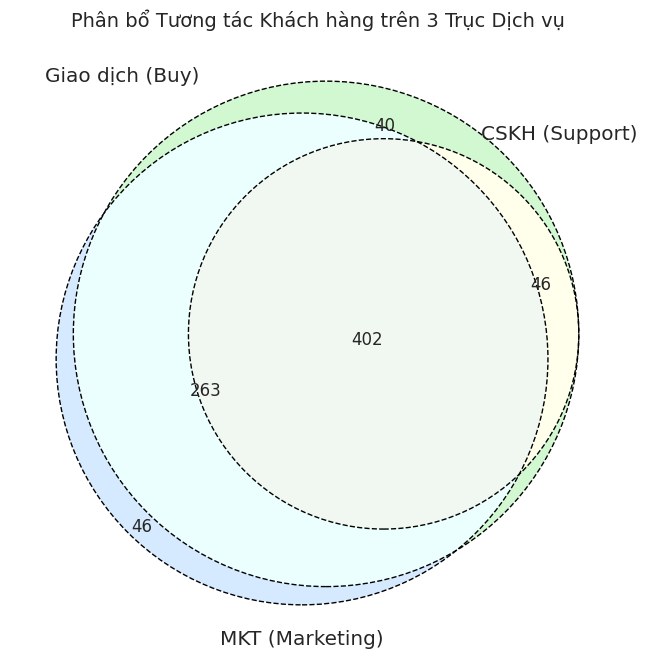

In [ ]:
# 1. Tìm tập hợp Customer id của từng dịch vụ
try:
    from matplotlib_venn import venn3, venn3_circles
except ImportError:
    # Nếu chưa install thư viện, chạy subprocess fallback
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "matplotlib-venn"])
    from matplotlib_venn import venn3, venn3_circles

import matplotlib.pyplot as plt

cust_base = set(customers['customer_id'])
cust_buy = set(transactions['customer_id'])
cust_sup = set(support['customer_id'])
cust_mkt = set(marketing['customer_id'])

# Đếm khách mồ côi
print(f"Tổng tệp Khách: {len(cust_base)}")
print(f"Khách có mua: {len(cust_buy)}")
print(f"KH NẰM NGOÀI MỌI HOẠT ĐỘNG (No Buy, No Sup, No Mkt): {len(cust_base - cust_buy - cust_sup - cust_mkt)} VIP")
print(f"Khách Mua MÀ KHÔNG Bị SPAM MKT: {len(cust_buy - cust_mkt)}")

# 2. Vẽ Venn biểu diễn độ phủ
plt.figure(figsize=(10, 8))
venn = venn3(
    subsets=[cust_buy, cust_sup, cust_mkt],
    set_labels=('Giao dịch (Buy)', 'CSKH (Support)', 'MKT (Marketing)'),
    set_colors=('#90EE90', '#FF9999', '#99CCFF')
)
venn3_circles(subsets=[cust_buy, cust_sup, cust_mkt], linestyle='dashed', linewidth=1, color="black")
plt.title('Phân bổ Tương tác Khách hàng trên 3 Trục Dịch vụ')
plt.show()


In [ ]:
# Đo lường Độ phủ Thông tin Đa chiều (Cross-domain Coverage)
total_cust = len(cust_base)
coverage_buy = len(cust_base & cust_buy) / total_cust * 100
coverage_mkt = len(cust_base & cust_mkt) / total_cust * 100
coverage_sup = len(cust_base & cust_sup) / total_cust * 100

print(f"===== ĐỘ PHỦ THÔNG TIN ĐA CHIỀU (Cross-domain Coverage) =====")
print(f"Tổng KH trên hệ thống (Base):          {total_cust}")
print(f"KH có phát sinh Giao dịch (Buy):        {len(cust_base & cust_buy):>4} / {total_cust}  ({coverage_buy:.1f}%)")
print(f"KH có vết trong Marketing (MKT):        {len(cust_base & cust_mkt):>4} / {total_cust}  ({coverage_mkt:.1f}%)")
print(f"KH có tương tác Hỗ trợ (Support):       {len(cust_base & cust_sup):>4} / {total_cust}  ({coverage_sup:.1f}%)")

===== ĐỘ PHỦ THÔNG TIN ĐA CHIỀU (Cross-domain Coverage) =====
Tổng KH trên hệ thống (Base):          800
KH có phát sinh Giao dịch (Buy):         751 / 800  (93.9%)
KH có vết trong Marketing (MKT):         711 / 800  (88.9%)
KH có tương tác Hỗ trợ (Support):        448 / 800  (56.0%)


In [ ]:
# 1. Đo lường Tổng giá trị thô (Raw Cost) trên từng dòng Mặt hàng (Item_Level)
# Không sử dụng hàm abs() để lợi dụng số Âm trừ lùi Doanh thu Refund.
transaction_items['raw_cost'] = transaction_items['quantity'] * transaction_items['unit_price']

# 2. Thuật toán Cuộn dữ liệu (Roll-up Aggregation) về Lớp Giao dịch (Transaction_Level)
tx_cost_agg = transaction_items.groupby('transaction_id', as_index=False).agg(
    total_raw_amount=('raw_cost', 'sum')
)

# 3. Phép nối Giai đoạn 1 (First Merge) vách ngăn Transaction
transactions = transactions.merge(tx_cost_agg, on='transaction_id', how='left')

# 4. Hiệu chỉnh Khuyến mại (Discount Calibration)
transactions['discount_applied'] = transactions['discount_applied'].fillna(0) # Trám 0% với các KH nguyên giá

# 5. Kết xuất Doanh Thu Tổng Cuối (Total Final Amount)
transactions['total_amount'] = transactions['total_raw_amount'] * (1 - transactions['discount_applied'] / 100)

print("Kiểm định Doanh Thu Thuần sau Khôi Phục (Net Revenue Dump):")
print(transactions[['transaction_id', 'total_raw_amount', 'discount_applied', 'total_amount']].head(5))

Kiểm định Doanh Thu Thuần sau Khôi Phục (Net Revenue Dump):
  transaction_id  total_raw_amount  discount_applied  total_amount
0        T000001         1710000.0              0.20     1706580.0
1        T000002       149082000.0              0.00   149082000.0
2        T000003         4836000.0              0.00     4836000.0
3        T000004        10223000.0              0.15    10207665.5
4        T000005        73539000.0              0.05    73502230.5


In [ ]:
# 1. Thu gọn Hành vi GIAO DỊCH (Transactions) + PRODUCTS
# Join products vào transaction_items
tx_items_ext = transaction_items.merge(products[['product_id', 'category', 'brand']], on='product_id', how='left')

# Tính toán các đặc trưng phức tạp hơn
tx_items_features = tx_items_ext.groupby('transaction_id').agg(
    unique_categories=('category', 'nunique'),
    brands_bought=('brand', lambda x: x.mode()[0] if not x.mode().empty else 'Unknown')
).reset_index()

transactions_rich = transactions.merge(tx_items_features, on='transaction_id', how='left')

tx_features = transactions_rich.groupby('customer_id').agg(
    total_transactions_count=('transaction_id', 'count'),
    total_lifetime_value=('total_amount', 'sum'),
    avg_discount_rate=('discount_applied', 'mean'),
    lifetime_categories=('unique_categories', 'max'), # Max unique cate per order
    lifetime_favorite_brand=('brands_bought', lambda x: x.mode()[0] if not x.mode().empty else 'Unknown')
).reset_index()

# 2. Thu gọn Hành vi SUPPORT (Customer Care)
sup_features = support.groupby('customer_id').agg(
    total_support_tickets=('ticket_id', 'count'),
    avg_satisfaction_score=('satisfaction_score', 'mean'), # Bỏ qua NaN tự động
    resolved_tickets=('resolution_status', lambda x: (x == 'Resolved').sum())
).reset_index()
sup_features['resolved_rate'] = (sup_features['resolved_tickets'] / sup_features['total_support_tickets']).fillna(0)
sup_features.drop(columns=['resolved_tickets'], inplace=True)

# 3. Thu gọn Hành vi MARKETING (Touchpoints)
mkt_features = marketing.groupby('customer_id').agg(
    total_campaigns_received=('campaign_id', 'count'),
    total_marketing_opens=('is_opened', 'sum'),
    total_marketing_clicks=('is_clicked', 'sum'),
    total_offer_value=('offer_value', 'sum')
).reset_index()

# THE GRAND MERGE: Ráp vào Giao thức xương sống Base Table bằng LEFT JOIN có BẢO VỆ 1:1
df_master = customers.copy()

for feat_df, df_name in zip([tx_features, sup_features, mkt_features], ['Giao Dịch', 'Support', 'Marketing']):
    df_master = df_master.merge(feat_df, on='customer_id', how='left', validate='1:1')

# Bơm Missing Value bằng 0 (Do kết quả của LEFT JOIN với KH mồ côi)
fill_cols = [
    'total_transactions_count', 'total_lifetime_value', 'avg_discount_rate',
    'total_support_tickets', 'total_campaigns_received',
    'total_marketing_opens', 'total_marketing_clicks', 'total_offer_value',
    'avg_satisfaction_score', 'resolved_rate', 'lifetime_categories'
]
df_master[fill_cols] = df_master[fill_cols].fillna(0)
df_master['lifetime_favorite_brand'] = df_master['lifetime_favorite_brand'].fillna('Unknown')

# Check Final Matrix
# Check Final Matrix
print("Tổng quan Cấu trúc của Siêu Bảng Dữ liệu (Master Data):")
print(f"Tổng số lượng Khách hàng: {df_master.shape[0]} người (Dòng)")
print(f"Tổng số lượng Bộ Đặc trưng: {df_master.shape[1]} biến (Cột)")
print("\nTrích xuất thử nghiệm 5 khách hàng đầu tiên trong hệ thống:")
print(df_master[['customer_id', 'total_support_tickets', 'resolved_rate', 'avg_satisfaction_score']].head(5))

Tổng quan Cấu trúc của Siêu Bảng Dữ liệu (Master Data):
Tổng số lượng Khách hàng: 800 người (Dòng)
Tổng số lượng Bộ Đặc trưng: 18 biến (Cột)

Trích xuất thử nghiệm 5 khách hàng đầu tiên trong hệ thống:
  customer_id  total_support_tickets  resolved_rate  avg_satisfaction_score
0      C00001                    0.0       0.000000                0.000000
1      C00002                    0.0       0.000000                0.000000
2      C00003                    1.0       1.000000                5.000000
3      C00004                    3.0       0.666667                5.000000
4      C00005                    3.0       1.000000                3.333333


#khởi tạo

In [ ]:
# 1. Đưa các trường biến Thời gian về định dạng chuẩn
transactions['transaction_date'] = pd.to_datetime(transactions['transaction_date'], errors='coerce')
marketing['sent_date'] = pd.to_datetime(marketing['sent_date'], errors='coerce')
support['created_date'] = pd.to_datetime(support['created_date'], errors='coerce')

# 2. Lấy mốc thời gian lớn nhất để làm điểm neo tịnh tiến lùi
max_date = transactions['transaction_date'].max()

print(f"Mốc thời gian lớn nhất đo được (Max Date): {max_date.date()}")
print("Khởi chạy Tiến trình Trượt Cửa sổ Thời gian...\n")

windows_days = [30, 60, 90]
all_datasets = []

for w in windows_days:
    snapshot_date = max_date - pd.Timedelta(days=w)

    # -----------------------------
    # BƯỚC 1: XÁC ĐỊNH NHÃN CHUẨN ĐOÁN (30 Ngày kế tiếp của mốc đó)
    # -----------------------------
    future_30d = snapshot_date + pd.Timedelta(days=30)
    target_window_tx = transactions[(transactions['transaction_date'] >= snapshot_date) &
                                    (transactions['transaction_date'] < future_30d)]

    retained_customers = set(target_window_tx['customer_id'].unique())

    # Khung dữ liệu nền tảng cho mốc thời gian trượt này
    df_window = customers[['customer_id', 'gender', 'birth_year', 'acquisition_channel']].copy()
    df_window['will_return_within_30_days'] = df_window['customer_id'].apply(lambda x: 1 if x in retained_customers else 0)
    df_window['snapshot_label'] = f"T-{w}"

    # -----------------------------
    # BƯỚC 2: TÍNH TOÁN CÁC CHỈ BÁO HÀNH VI TỪ DỮ LIỆU QUÁ KHỨ CỦA MỐC ĐÓ
    # -----------------------------
    past_tx = transactions[transactions['transaction_date'] < snapshot_date]
    past_mkt = marketing[marketing['sent_date'] < snapshot_date]
    past_sup = support[support['created_date'] < snapshot_date]

    # Nối sẵn thông tin Món hàng và Cửa hàng vào Giao dịch để xem sở thích
    past_tx_items = transaction_items.merge(products[['product_id', 'category', 'brand']], on='product_id', how='left')
    past_tx_brands = past_tx.merge(past_tx_items, on='transaction_id', how='left')
    past_tx_brands = past_tx_brands.merge(stores[['store_id', 'store_type']], on='store_id', how='left')

    # B.1: Khai phá RFM & Khẩu vị Nhãn Hàng, Kênh Mua
    rfm = past_tx_brands.groupby('customer_id').agg(
        last_purchase_date=('transaction_date', 'max'), #tìm ngày mua hàng gần nhất (dùng để tính recency ở bước 2)
        frequency_total=('transaction_id', 'nunique'), #đếm số lượng đơn hàng (chỉ số F - tần suất trong FRM)
        monetary_total=('total_amount', 'mean'), # Dùng Trung bình hóa đơn để rải đều trọng số giá trị
        avg_discount_used=('discount_applied', 'mean'),
        favorite_brand=('brand', lambda x: x.mode()[0] if not x.mode().empty else 'Unknown'),
        unique_categories=('category', 'nunique'),
        online_shopping_ratio=('store_type', lambda x: (x == 'Online').mean())
    ).reset_index()

    # B.2: Khoảng cách thời gian trung bình giữa các lần mua
    past_tx_sorted = past_tx.sort_values(['customer_id', 'transaction_date'])
    past_tx_sorted['prev_date'] = past_tx_sorted.groupby('customer_id')['transaction_date'].shift(1)
    #để đẩy ngày mua của đơn hàng trước đó xuống cùng một dòng với đơn hàng hiện tại. Phép trừ 2 ngày này sẽ ra được days_last_purchase (khoảng cách nghỉ giữa 2 lần)
    past_tx_sorted['days_since_last_purchase'] = (past_tx_sorted['transaction_date'] - past_tx_sorted['prev_date']).dt.days
    interval_df = past_tx_sorted.groupby('customer_id').agg(
        inter_purchase_interval=('days_since_last_purchase', 'mean'),# trung bình các khoảng cách nghỉ, cho biết cứ bao nhiêu trung bình bao nhiêu ngày thì KH lại chốt đơn
        favorite_shopping_day=('transaction_date', lambda x: x.dt.dayofweek.mode()[0] if not x.dt.dayofweek.mode().empty else -1),
        #tìm ra thứ trong tuần và tháng trong năm mà khách hay mua nhất
        favorite_shopping_month=('transaction_date', lambda x: x.dt.month.mode()[0] if not x.dt.month.mode().empty else -1) # Đại diện cho vòng lặp mùa vụ
    ).reset_index()
    rfm = rfm.merge(interval_df, on='customer_id', how='left')

    # Chuyển Ngày mua cuối thành Số ngày từ đó đến cột mốc (Recency)
    rfm['recency_days'] = (snapshot_date - rfm['last_purchase_date']).dt.days
    rfm.drop(columns=['last_purchase_date'], inplace=True)

    # B.3: Tương tác với Quảng cáo (Tỉ lệ Mở & Giá trị khuyến mãi)
    mkt_agg = past_mkt.groupby('customer_id').agg(
        total_campaigns=('campaign_id', 'count'),
        total_opens=('is_opened', 'sum'),
        total_clicks=('is_clicked', 'sum'),
        total_offer_value=('offer_value', 'sum')
    ).reset_index()
    mkt_agg['marketing_open_rate'] = (mkt_agg['total_opens'] / mkt_agg['total_campaigns']).fillna(0)
    mkt_agg['marketing_ctr'] = (mkt_agg['total_clicks'] / mkt_agg['total_opens']).fillna(0)
    mkt_agg.loc[mkt_agg['marketing_open_rate'] > 1, 'marketing_open_rate'] = 1.0 # Đóng trần tối đa 1.0
    mkt_agg.loc[mkt_agg['marketing_ctr'] > 1, 'marketing_ctr'] = 1.0 # Đóng trần tối đa 1.0

    # B.4: Tương tác bộ phận Chăm sóc Khách hàng
    sup_agg = past_sup.groupby('customer_id').agg(
        total_tickets=('ticket_id', 'count'),
        resolved_tickets=('resolution_status', lambda x: (x == 'Resolved').sum()),
        avg_satisfaction_score=('satisfaction_score', 'mean')
    ).reset_index()
    sup_agg['resolved_rate'] = (sup_agg['resolved_tickets'] / sup_agg['total_tickets']).fillna(0)
    sup_agg.drop(columns=['resolved_tickets'], inplace=True) # Khử đi biến đã dùng để tính tỉ lệ, nhưng vẫn chừa lại Cột Tổng số Phiếu Hỗ trợ như yêu cầu

    # -----------------------------
    # BƯỚC 3: KẾT DÍNH DỮ LIỆU
    # -----------------------------
    df_window = df_window.merge(rfm, on='customer_id', how='left')
    # Kéo thêm biến số lượng Quảng cáo như yêu cầu đề bài
    df_window = df_window.merge(mkt_agg[['customer_id', 'total_campaigns', 'marketing_open_rate', 'marketing_ctr', 'total_offer_value']], on='customer_id', how='left')
    df_window = df_window.merge(sup_agg, on='customer_id', how='left')

    all_datasets.append(df_window)

# Gộp các Cửa sổ Thời gian lại thành Bảng Tổng
ml_dataset = pd.concat(all_datasets, ignore_index=True)

# Lấp đầy các trường hợp Khách hàng chưa tương tác với giá trị 0
ml_dataset['frequency_total'] = ml_dataset['frequency_total'].fillna(0)
ml_dataset['monetary_total'] = ml_dataset['monetary_total'].fillna(0)
ml_dataset['recency_days'] = ml_dataset['recency_days'].fillna(999) # Chấp nhận thiết lập số lớn cho những người chưa mua bao giờ
ml_dataset['avg_discount_used'] = ml_dataset['avg_discount_used'].fillna(0)
ml_dataset['unique_categories'] = ml_dataset['unique_categories'].fillna(0)
ml_dataset['favorite_brand'] = ml_dataset['favorite_brand'].fillna('Unknown')
ml_dataset['online_shopping_ratio'] = ml_dataset['online_shopping_ratio'].fillna(0)
ml_dataset['favorite_shopping_day'] = ml_dataset['favorite_shopping_day'].fillna(-1)
ml_dataset['favorite_shopping_month'] = ml_dataset['favorite_shopping_month'].fillna(-1)
ml_dataset['total_campaigns'] = ml_dataset['total_campaigns'].fillna(0)
ml_dataset['total_tickets'] = ml_dataset['total_tickets'].fillna(0)
ml_dataset['marketing_open_rate'] = ml_dataset['marketing_open_rate'].fillna(0)
ml_dataset['marketing_ctr'] = ml_dataset['marketing_ctr'].fillna(0)
ml_dataset['total_offer_value'] = ml_dataset['total_offer_value'].fillna(0)
ml_dataset['resolved_rate'] = ml_dataset['resolved_rate'].fillna(0)

# Một số biến trống khoảng cách hay điểm đánh giá sẽ được bảo toàn để giữ nguyên ý nghĩa
# Thuật toán XGBoost thông minh tự xử lý được biến Trống

# Mã hoá Khảo sát Tần suất: Lọc bỏ chữ để đổi thành chỉ số đếm tần suất lặp lại
brand_freq = ml_dataset['favorite_brand'].value_counts().to_dict()
ml_dataset['brand_freq_encoded'] = ml_dataset['favorite_brand'].map(brand_freq)
ml_dataset.drop(columns=['favorite_brand'], inplace=True)

# Tính toán Tuổi thọ hiện tại theo Mốc thời điểm
ml_dataset['age'] = 2026 - ml_dataset['birth_year']
ml_dataset['age'] = ml_dataset['age'].fillna(ml_dataset['age'].median())

Mốc thời gian lớn nhất đo được (Max Date): 2026-03-25
Khởi chạy Tiến trình Trượt Cửa sổ Thời gian...



In [ ]:
print("=============================================")
print("HOÀN TẤT CHUẨN BỊ DỮ LIỆU MACHINE LEARNING")
print(f"Tổng Lượng Mẫu (Rows): {ml_dataset.shape[0]} (Đã x3 dữ liệu qua các mốc thời gian từ {ml_dataset['customer_id'].nunique()} khách hàng gốc)")
print(f"Số lượng Đặc trưng (Features): {ml_dataset.shape[1]}")
print("\nTỉ lệ Nhãn Mục tiêu (Churn / Retain - Bao gồm cả biến động Mùa vụ):")
display(ml_dataset['will_return_within_30_days'].value_counts(normalize=True).round(3) * 100)

HOÀN TẤT CHUẨN BỊ DỮ LIỆU MACHINE LEARNING
Tổng Lượng Mẫu (Rows): 2400 (Đã x3 dữ liệu qua các mốc thời gian từ 800 khách hàng gốc)
Số lượng Đặc trưng (Features): 24

Tỉ lệ Nhãn Mục tiêu (Churn / Retain - Bao gồm cả biến động Mùa vụ):


,proportion
will_return_within_30_days,
0,81.0
1,19.0


In [ ]:
display(ml_dataset[ml_dataset['customer_id'] == 'C00001'][['snapshot_label', 'will_return_within_30_days', 'recency_days', 'frequency_total', 'monetary_total']])


,snapshot_label,will_return_within_30_days,recency_days,frequency_total,monetary_total
0,T-30,0,22.0,10.0,1.185411e+07
800,T-60,1,3.0,9.0,9.857651e+06
1600,T-90,1,69.0,8.0,1.053640e+07


#huấn luyện mô hình

In [ ]:
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Tiền xử lý Dữ liệu Định tính thành dạng Nhị phân (One-Hot Encoding)
df_ml = ml_dataset.copy()
df_ml['gender'] = df_ml['gender'].fillna('Unknown')
df_ml['acquisition_channel'] = df_ml['acquisition_channel'].fillna('Unknown')

# Tạo biến giả và bỏ cột đầu tiên để tránh hiện tượng Đa cộng tuyến
df_ml = pd.get_dummies(df_ml, columns=['gender', 'acquisition_channel'], drop_first=True)

# 2. Phân tách tập Huấn luyện và Kiểm thử theo Trục thời gian thực
# Tuân thủ yêu cầu: Không chia ngẫu nhiên mà tách theo dòng thời gian (Out-of-Time check)
train_mask = df_ml['snapshot_label'].isin(['T-90', 'T-60'])
test_mask = df_ml['snapshot_label'] == 'T-30'

# Loại bỏ các cột mã định danh và nhãn gốc không dùng để dự báo
drop_cols = ['customer_id', 'snapshot_label', 'will_return_within_30_days', 'birth_year']

X_train = df_ml[train_mask].drop(columns=drop_cols)
y_train = df_ml[train_mask]['will_return_within_30_days']

X_test = df_ml[test_mask].drop(columns=drop_cols)
y_test = df_ml[test_mask]['will_return_within_30_days']

print(f"Lượng Dữ liệu Huấn Luyện X_train (Mốc quá khứ T-90, T-60): {X_train.shape[0]} Mẫu")
print(f"Lượng Dữ liệu Kiểm Thử X_test (Mốc hiện tại T-30): {X_test.shape[0]} Mẫu")

# Tính toán Tỷ lệ Mất cân bằng Lớp để Phân bổ Trọng số
scale_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Trọng số cân bằng nhóm (Scale_Pos_Weight) trên tập Huấn luyện: {scale_weight:.2f}")

Lượng Dữ liệu Huấn Luyện X_train (Mốc quá khứ T-90, T-60): 1600 Mẫu
Lượng Dữ liệu Kiểm Thử X_test (Mốc hiện tại T-30): 800 Mẫu
Trọng số cân bằng nhóm (Scale_Pos_Weight) trên tập Huấn luyện: 4.33


In [ ]:
# 3. Mô hình Tiêu chuẩn (Baseline: Logistic Regression)
# Logistic Regression yêu cầu chuẩn hóa dữ liệu (Scaling) và không chấp nhận giá trị khuyết (NaN).
# Do đó, thuật toán được cấu trúc gọn gàng qua một Pipeline kết hợp SimpleImputer và StandardScaler.
from sklearn.impute import SimpleImputer

log_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))
])

log_pipeline.fit(X_train, y_train)
lr_pred = log_pipeline.predict(X_test)
lr_prob = log_pipeline.predict_proba(X_test)[:, 1]

lr_roc = roc_auc_score(y_test, lr_prob)
print(f"Hiệu năng ROC-AUC (Cơ sở) của Logistic Regression: {lr_roc:.3f}")

Hiệu năng ROC-AUC (Cơ sở) của Logistic Regression: 0.675


In [ ]:
# 4. Tối ưu Mô hình Nâng cao (XGBoost với GridSearchCV)
xgb_base = xgb.XGBClassifier(
    scale_pos_weight=scale_weight,
    random_state=42,
    use_label_encoder=False,
    eval_metric='auc'
)

# Kéo Lưới Ma Trận Tìm Tham Số (GridSearch)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

best_xgb = grid_search.best_estimator_
xgb_pred = best_xgb.predict(X_test)
xgb_prob = best_xgb.predict_proba(X_test)[:, 1]

xgb_roc = roc_auc_score(y_test, xgb_prob)
print(f"Hiệu năng ROC-AUC Tối ưu của XGBoost (GridSearch): {xgb_roc:.3f}")
print(f"Bộ tham số XGBoost nội sinh tốt nhất (Best_Params): {grid_search.best_params_}")

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Hiệu năng ROC-AUC Tối ưu của XGBoost (GridSearch): 0.670
Bộ tham số XGBoost nội sinh tốt nhất (Best_Params): {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}


== BASELINE: LOGISTIC REGRESSION ==
              precision    recall  f1-score   support

 0 (Churned)       0.87      0.67      0.76       643
1 (Retained)       0.31      0.60      0.40       157

    accuracy                           0.65       800
   macro avg       0.59      0.63      0.58       800
weighted avg       0.76      0.65      0.69       800


== OPTIMIZED MODEL: XGBOOST ==
              precision    recall  f1-score   support

 0 (Churned)       0.86      0.77      0.81       643
1 (Retained)       0.33      0.46      0.39       157

    accuracy                           0.71       800
   macro avg       0.60      0.62      0.60       800
weighted avg       0.75      0.71      0.73       800



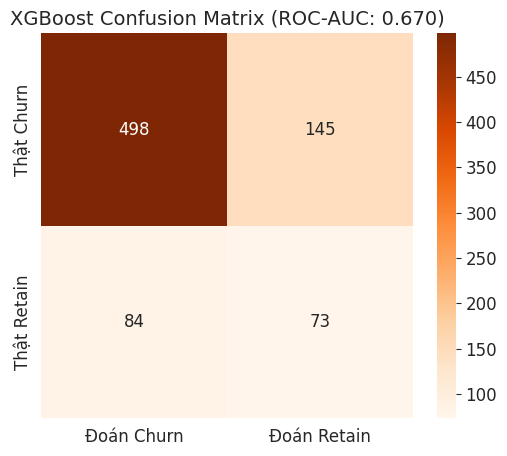

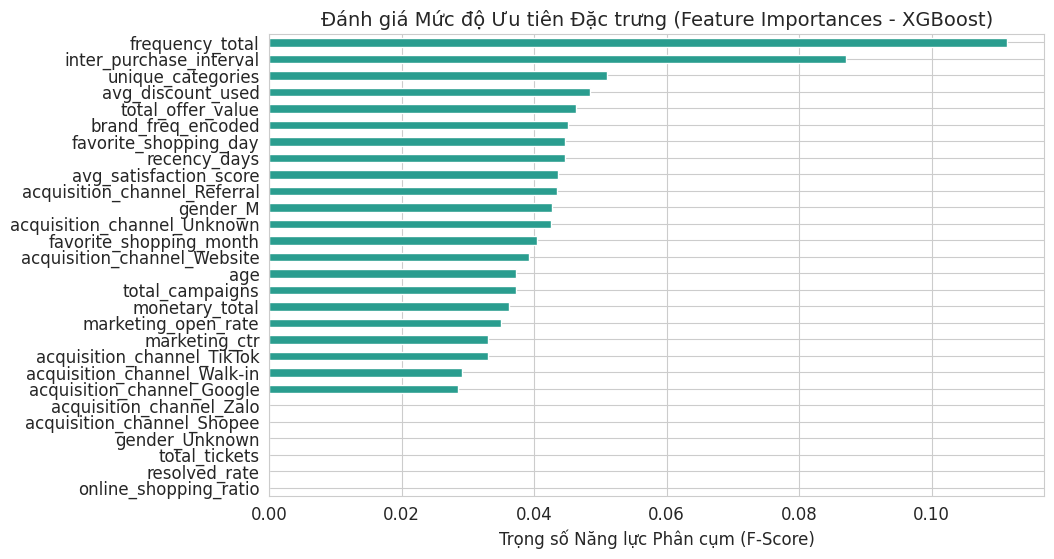

In [ ]:
# 5. ĐÁNH GIÁ CHUYÊN SÂU (CLASSIFICATION REPORT & CONFUSION MATRIX)
print("== BASELINE: LOGISTIC REGRESSION ==")
print(classification_report(y_test, lr_pred, target_names=['0 (Churned)', '1 (Retained)']))

print("\n== OPTIMIZED MODEL: XGBOOST ==")
print(classification_report(y_test, xgb_pred, target_names=['0 (Churned)', '1 (Retained)']))

# MA TRẬN NHẦM LẪN XGBOOST
plt.figure(figsize=(6,5))
cm = confusion_matrix(y_test, xgb_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=['Đoán Churn', 'Đoán Retain'], yticklabels=['Thật Churn', 'Thật Retain'])
plt.title(f'XGBoost Confusion Matrix (ROC-AUC: {xgb_roc:.3f})')
plt.show()

# ĐÁNH GIÁ MỨC ĐỘ QUAN TRỌNG ĐẶC TRƯNG (FEATURE IMPORTANCE)
plt.figure(figsize=(10,6))
feature_importances = pd.Series(best_xgb.feature_importances_, index=X_train.columns).sort_values(ascending=True)
feature_importances.plot(kind='barh', color='#2a9d8f')
plt.title("Đánh giá Mức độ Ưu tiên Đặc trưng (Feature Importances - XGBoost)")
plt.xlabel("Trọng số Năng lực Phân cụm (F-Score)")
plt.show()